In [3]:
from src.data_loaders.dataset import get_data_loaders


cfg={
    "batch_size": 32,
        "num_workers": 0,

}
train_loader, valid_loader, test_loader = get_data_loaders(cfg=cfg)


Train: 100000 | Valid: 20000 | Test: 20000



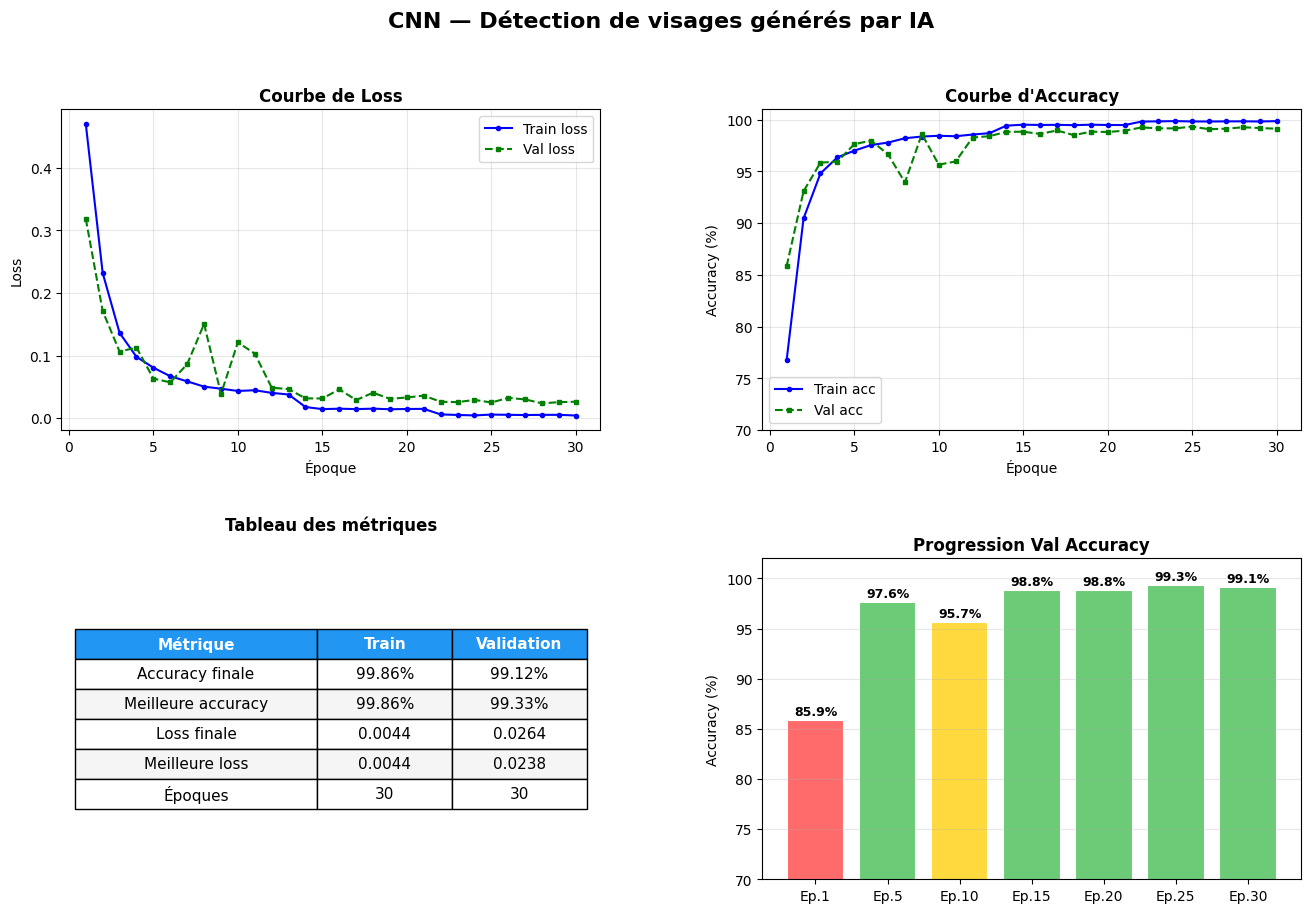

Sauvegarde : output/visualisations_finales.png


In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

with open('output/exp_01_history.json') as f:
    history = json.load(f)

train_loss = [e['loss'] for e in history['train']]
val_loss   = [e['loss'] for e in history['valid']]
train_acc  = [e['acc']  for e in history['train']]
val_acc    = [e['acc']  for e in history['valid']]
epochs     = range(1, len(train_loss)+1)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('CNN — Détection de visages générés par IA', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, train_loss, 'b-o', markersize=3, label='Train loss')
ax1.plot(epochs, val_loss, 'g--s', markersize=3, label='Val loss')
ax1.set_title('Courbe de Loss', fontweight='bold')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, [a*100 for a in train_acc], 'b-o', markersize=3, label='Train acc')
ax2.plot(epochs, [a*100 for a in val_acc], 'g--s', markersize=3, label='Val acc')
ax2.set_title("Courbe d'Accuracy", fontweight='bold')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([70, 101])
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
metrics = [
    ['Métrique', 'Train', 'Validation'],
    ['Accuracy finale', f'{train_acc[-1]*100:.2f}%', f'{val_acc[-1]*100:.2f}%'],
    ['Meilleure accuracy', f'{max(train_acc)*100:.2f}%', f'{max(val_acc)*100:.2f}%'],
    ['Loss finale', f'{train_loss[-1]:.4f}', f'{val_loss[-1]:.4f}'],
    ['Meilleure loss', f'{min(train_loss):.4f}', f'{min(val_loss):.4f}'],
    ['Époques', '30', '30'],
]
table = ax3.table(cellText=metrics[1:], colLabels=metrics[0],
                  cellLoc='center', loc='center', colWidths=[0.45, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2196F3')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f5f5f5')
ax3.set_title('Tableau des métriques', fontweight='bold', pad=20)

ax4 = fig.add_subplot(gs[1, 1])
indices = [0, 4, 9, 14, 19, 24, 29]
labels = ['Ep.1', 'Ep.5', 'Ep.10', 'Ep.15', 'Ep.20', 'Ep.25', 'Ep.30']
vals = [val_acc[i]*100 for i in indices]
colors = ['#ff6b6b' if v < 90 else '#ffd93d' if v < 96 else '#6bcb77' for v in vals]
bars = ax4.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Progression Val Accuracy', fontweight='bold')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim([70, 102])
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('output/visualisations_finales.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Sauvegarde : output/visualisations_finales.png")